## Set up

In [2]:
from doc_uploader import DocUploader
from db import Database
from vector_db import VectorDB
from google.cloud import storage 
from dotenv import load_dotenv
import os
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

_ = load_dotenv()

PGHOST=os.environ.get("PGHOST")
PGPORT=os.environ.get("PGPORT")
PGUSER=os.environ.get("PGUSER")
PGDATABASE=os.environ.get("PGDATABASE")

openai_api_key = os.environ.get("OPENAI_API_KEY")
anthropic_api_key = os.environ.get("ANTHROPIC_API_KEY")
gcp_project = os.environ.get("GOOGLE_CLOUD_PROJECT")

print("gcp_project", gcp_project)

storage_client = storage.Client(project=gcp_project)
bucket = storage_client.get_bucket("fyp_pdfs")

qdrant_url = "localhost"
qdrant_port = 6333
collection_a = "fyp_vectors_naive_small"
collection_b = "fyp_vectors_smart_small"

vdb_collection_a = VectorDB(url=qdrant_url, port=qdrant_port, collection_name=collection_a)
vdb_collection_a._setup()
vdb_collection_b = VectorDB(url=qdrant_url, port=qdrant_port, collection_name=collection_b)
vdb_collection_b._setup()


PGURI=f"postgresql://{PGUSER}@{PGHOST}:{PGPORT}/{PGDATABASE}"
db = Database(conn_string=PGURI)
db._setup()

llm = ChatOpenAI(
    streaming=True,
    verbose=True,
    temperature=0,
    openai_api_key=openai_api_key,
    model="gpt-4-0125-preview",
).with_retry()

gcp_project nus-fyp-416909
2024-04-03 22:14:54,124 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2024-04-03 22:14:54,124 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-04-03 22:14:54,128 INFO sqlalchemy.engine.Engine select current_schema()
2024-04-03 22:14:54,129 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-04-03 22:14:54,133 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2024-04-03 22:14:54,133 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-04-03 22:14:54,165 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2024-04-03 22:14:54,166 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_nam

## Some utils

In [3]:
def upload_file_to_gcs(file_path):
    file_name = file_path.split("/")[-1]
    blob = bucket.blob(file_name)
    blob.upload_from_filename(file_path)
    return blob

from urllib.parse import unquote_plus

def get_blob_from_url(url):
    # Extract the blob name from the URL after the last '/'
    blob_name = url.split("/")[-1]
    # URL decode the blob name to handle spaces and other special characters
    decoded_blob_name = unquote_plus(blob_name)
    # Retrieve the blob using the decoded name
    blob = bucket.blob(decoded_blob_name)
    return blob

## Load into vector database for both systems

In [4]:
# doc uploader for naive collection
doc_uploader_naive = DocUploader(
    is_nerfed=True,
    storage_client=storage_client,
    bucket=bucket,
    blob=blob,
    db=db,
    vector_db=vdb_collection_a
)

doc_uploader_smart = DocUploader(
    is_nerfed=False,
    storage_client=storage_client,
    bucket=bucket,
    blob=blob,
    db=db,
    vector_db=vdb_collection_b
)

In [ ]:
# call parse for both
await doc_uploader_naive.parse()
await doc_uploader_smart.parse()

## RAGAS for both systems

In [6]:
questions = [
    "What is the startup's competitive advantage/moat?",
    "What can we infer about the market size for the startup's product or service?",
    "What is the potential market opportunity for the startup's product or service?",
    "What is the startup's revenue this year and last year, taking this year as 2024?",
    "What are the startup's expenses this year and last year, taking this year as 2024?",
    "What is the customer acquisition cost (CAC)?",
    "What is the retention cost?",
    "What is the customer lifetime value (CLTV)?",
    "What are the profitability trends for the startup?"
]

modified_prompt_template = lambda doc_name, context, question: f"""
All context are extracted from a document named {doc_name}.
Using the provided context (refer to this as your knowledge base), answer the question in detail and provide insightful explanations. Use the context as much as possible and quote relevant parts of the context to support your answer.
If the context is not enough to answer the question, respond with "My knowledge base is not sufficient to answer the question."

Context:
{context}

Question:
{question}
"""

In [8]:
# build out the prompts for naive and smart systems 
prompts_naive = []
contexts_naive = []

for question in questions:
    curr_node_list = vdb_collection_a.retrieve_with_constaints(
        doc_id = doc_uploader_naive.uid,
        query = question
    )
    contexts = [node.text for node in curr_node_list]
    contexts_naive.append(contexts)
    context = "\n".join(contexts)
    prompt = modified_prompt_template(blob.name, context, question)
    prompts_naive.append(prompt)

prompts_smart = []
contexts_smart = []

for question in questions:
    curr_node_list = vdb_collection_b.retrieve_with_constaints(
        doc_id = doc_uploader_smart.uid,
        query = question
    )
    contexts = [node.text for node in curr_node_list]
    contexts_smart.append(contexts)
    context = "\n".join(contexts)
    prompt = modified_prompt_template(blob.name, context, question)
    prompts_smart.append(prompt)

In [14]:
naive_answers = [llm.invoke(prompt) for prompt in prompts_naive]

In [16]:
smarts_answers = [llm.invoke(prompt) for prompt in prompts_smart]

In [19]:
from datasets import Dataset 
from ragas.metrics import answer_relevancy
from ragas import evaluate

naive_data_samples = {
    'question': questions,
    'answer': naive_answers,
    'contexts': contexts_naive
}
dataset = Dataset.from_dict(naive_data_samples)
score = evaluate(dataset, metrics=[answer_relevancy])
naive_df = score.to_pandas()

/Users/ivankoh/miniconda/envs/fyp-backend/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating: 100%|██████████| 9/9 [00:08<00:00,  1.06it/s]


In [20]:
smart_data_samples = {
    'question': questions,
    'answer': smarts_answers,
    'contexts': contexts_smart
}
dataset = Dataset.from_dict(smart_data_samples)
score = evaluate(dataset, metrics=[answer_relevancy])
smart_df = score.to_pandas()

Evaluating: 100%|██████████| 9/9 [00:08<00:00,  1.12it/s]


In [21]:
naive_df['answer_relevancy'].mean()

0.29863299834571455

In [22]:
smart_df['answer_relevancy'].mean()

0.4650529987824551

## Do RAGAS evaluation on 15 documents 

In [3]:
# list all urls in the bucket
def list_blobs(bucket_name):
    blobs = storage_client.list_blobs(bucket_name)
    return [blob.name for blob in blobs]

def get_blob_url(blob_name):
    return f"https://storage.googleapis.com/{bucket.name}/{blob_name}"

from urllib.parse import unquote_plus

def get_blob_from_url(url):
    # Extract the blob name from the URL after the last '/'
    blob_name = url.split("/")[-1]
    # URL decode the blob name to handle spaces and other special characters
    decoded_blob_name = unquote_plus(blob_name)
    # Retrieve the blob using the decoded name
    blob = bucket.blob(decoded_blob_name)
    return blob

blob_names = list_blobs("fyp_pdfs")

urls = [get_blob_url(doc) for doc in blob_names][94:]


In [ ]:
from datasets import Dataset
from ragas.metrics import answer_relevancy
from ragas import evaluate
from pprint import pprint
eval_path = "eval/openai_context_size_five"

questions = [
    "What is the startup's competitive advantage/moat?",
    "What can we infer about the market size for the startup's product or service?",
    "What is the potential market opportunity for the startup's product or service?",
    "What is the startup's revenue this year and last year, taking this year as 2024?",
    "What are the startup's expenses this year and last year, taking this year as 2024?",
    "What is the customer acquisition cost (CAC)?",
    "What is the retention cost?",
    "What is the customer lifetime value (CLTV)?",
    "What are the profitability trends for the startup?"
]

modified_prompt_template = lambda doc_name, context, question: f"""
All context are extracted from a document named {doc_name}.
Using the provided context (refer to this as your knowledge base), answer the question in detail and provide insightful explanations. Use the context as much as possible and quote relevant parts of the context to support your answer.
If the context is not enough to answer the question, respond with "My knowledge base is not sufficient to answer the question."

Context:
{context}

Question:
{question}
"""

naive_dfs = []
smart_dfs = []

for url in urls:
    blob = get_blob_from_url(url)
    blob_name = blob.name

    # doc uploader for naive collection
    doc_uploader_naive = DocUploader(
        is_nerfed=True,
        storage_client=storage_client,
        bucket=bucket,
        blob=blob,
        db=db,
        vector_db=vdb_collection_a
    )

    doc_uploader_smart = DocUploader(
        is_nerfed=False,
        storage_client=storage_client,
        bucket=bucket,
        blob=blob,
        db=db,
        vector_db=vdb_collection_b
    )

    # call parse for both
    await doc_uploader_naive.parse()
    await doc_uploader_smart.parse()

    prompts_naive = []
    contexts_naive = []
    prompts_smart = []
    contexts_smart = []

    for question in questions:
        curr_node_list_naive = vdb_collection_a.retrieve_with_constaints(
            doc_id=doc_uploader_naive.uid,
            query=question
        )
        contexts_naive_doc = [node.text for node in curr_node_list_naive]
        contexts_naive.append(contexts_naive_doc)
        context_naive = "\n".join(contexts_naive_doc)
        prompt_naive = modified_prompt_template(blob_name, context_naive, question)
        prompts_naive.append(prompt_naive)

        curr_node_list_smart = vdb_collection_b.retrieve_with_constaints(
            doc_id=doc_uploader_smart.uid,
            query=question
        )
        contexts_smart_doc = [node.text for node in curr_node_list_smart]
        contexts_smart.append(contexts_smart_doc)
        context_smart = "\n".join(contexts_smart_doc)
        prompt_smart = modified_prompt_template(blob_name, context_smart, question)
        prompts_smart.append(prompt_smart)

    print(f"Getting naive answers for {blob_name}...")
    naive_answers = [llm.invoke(prompt).content for prompt in prompts_naive]
    print(f"Getting smart answers for {blob_name}...")
    smarts_answers = [llm.invoke(prompt).content for prompt in prompts_smart]

    naive_data_samples = {
        'question': questions,
        'answer': naive_answers,
        'contexts': contexts_naive
    }
    naive_dataset = Dataset.from_dict(naive_data_samples)
    naive_score = evaluate(naive_dataset, metrics=[answer_relevancy])
    naive_df = naive_score.to_pandas()
    naive_df.to_csv(os.path.join(eval_path, f"naive_{blob_name}.csv"))
    naive_dfs.append(naive_df)

    smart_data_samples = {
        'question': questions,
        'answer': smarts_answers,
        'contexts': contexts_smart
    }
    smart_dataset = Dataset.from_dict(smart_data_samples)
    smart_score = evaluate(smart_dataset, metrics=[answer_relevancy])
    smart_df = smart_score.to_pandas()
    smart_df.to_csv(os.path.join(eval_path, f"smart_{blob_name}.csv"))
    smart_dfs.append(smart_df)

# Calculate mean answer relevancy for each document
naive_means = [df['answer_relevancy'].mean() for df in naive_dfs]
smart_means = [df['answer_relevancy'].mean() for df in smart_dfs]

print("Naive system mean answer relevancy scores:")
print(naive_means)

print("Smart system mean answer relevancy scores:")
print(smart_means)

## Evaluation Results

In [19]:
import pandas as pd 
import os

eval_path = "eval/openai_context_size_five"
naive_eval_path = os.path.join(eval_path, "naive")
smart_eval_path = os.path.join(eval_path, "smart")


In [20]:
len(sorted(os.listdir(smart_eval_path)))

132

In [21]:
system_to_doc_to_mean = {
    "naive": {},
    "smart": {}
}

system_to_doc_to_median = {
    "naive": {},
    "smart": {}
}

for file in sorted(os.listdir(naive_eval_path)):
    # doc_name = file.split(".")[0].split("_")[1]
    doc_name = file[file.find("naive")+len('naive')+1:]
    df = pd.read_csv(os.path.join(naive_eval_path, file))
    system_to_doc_to_mean["naive"][doc_name] = df['answer_relevancy'].mean()
    system_to_doc_to_median["naive"][doc_name] = df['answer_relevancy'].median()

for file in sorted(os.listdir(smart_eval_path)):
    # doc_name = file.split(".")[0].split("_")[1]
    doc_name = file[file.find("smart")+len('naive')+1:]
    df = pd.read_csv(os.path.join(smart_eval_path, file))
    system_to_doc_to_mean["smart"][doc_name] = df['answer_relevancy'].mean()
    system_to_doc_to_median["smart"][doc_name] = df['answer_relevancy'].median()
    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# highlight those documents where the smart system outperforms the naive system
naive_means = list(system_to_doc_to_mean["naive"].values())
smart_means = list(system_to_doc_to_mean["smart"].values())
doc_names = list(system_to_doc_to_mean["naive"].keys())

df = pd.DataFrame({
    'Document': doc_names,
    'System Without Detection and Extraction': naive_means,
    'System With Detection and Extraction': smart_means
})

df = df.melt('Document', var_name='System', value_name='Mean Context Relevancy')
sns.set(rc={'figure.figsize':(15,9)})
sns.barplot(x='Document', y='Mean Context Relevancy', hue='System', data=df)
plt.title("Mean Context Relevancy for Each Document")  # Changed title as per instruction
# replace document names with doc_0, doc_1, etc.
plt.xticks(range(len(doc_names)), [f"doc_{i}" for i in range(len(doc_names))])
# highlight those documents where the smart system outperforms the naive system
for i, (naive_mean, smart_mean) in enumerate(zip(naive_means, smart_means)):
    if smart_mean > naive_mean:
        plt.gca().get_xticklabels()[i].set_color('red')
plt.show()


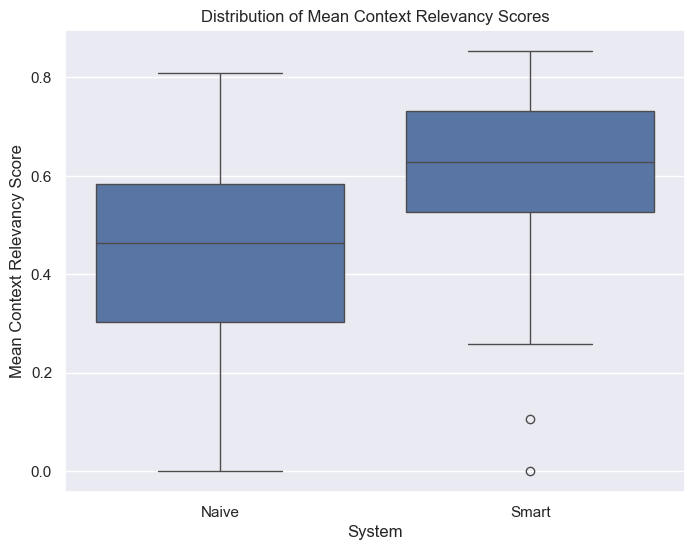

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
    'System': ['Naive'] * len(smart_means) + ['Smart'] * len(smart_means),
    'Score': naive_means + smart_means
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='System', y='Score', data=data)
# or sns.violinplot(x='System', y='Score', data=data)
plt.title('Distribution of Mean Context Relevancy Scores')
plt.xlabel('System')
plt.ylabel('Mean Context Relevancy Score')
plt.show()

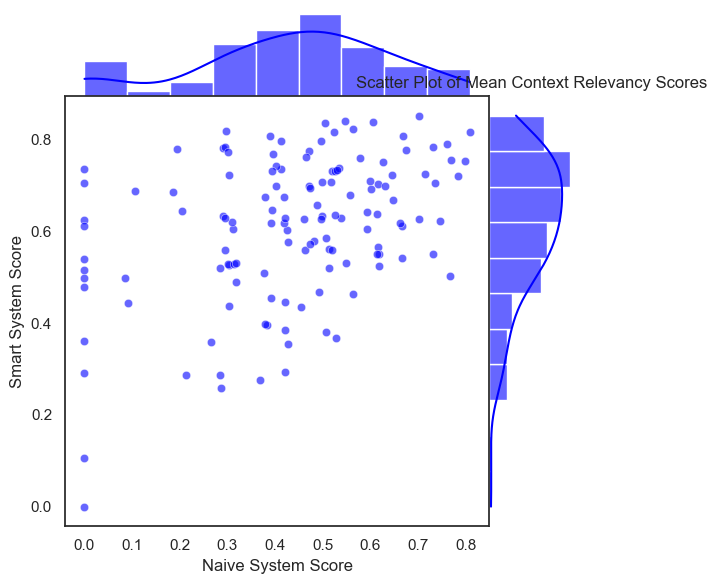

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
    'Naive System': naive_means,
    'Smart System': smart_means
})

sns.set(style='white')
g = sns.JointGrid(x='Naive System', y='Smart System', data=data, space=0)
g.plot_joint(sns.scatterplot, color='blue', alpha=0.6)
g.plot_marginals(sns.histplot, kde=True, color='blue', alpha=0.6)
g.set_axis_labels('Naive System Score', 'Smart System Score')
plt.title('Scatter Plot of Mean Context Relevancy Scores')
plt.show()

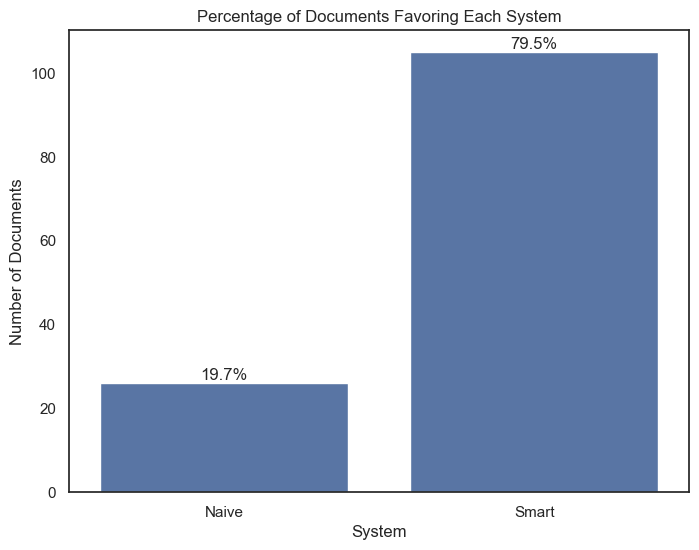

In [27]:
import matplotlib.pyplot as plt

naive_better = sum(naive_mean > smart_mean for naive_mean, smart_mean in zip(naive_means, smart_means))
smart_better = sum(smart_mean > naive_mean for naive_mean, smart_mean in zip(naive_means, smart_means))

data = pd.DataFrame({
    'System': ['Naive', 'Smart'],
    'Count': [naive_better, smart_better]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='System', y='Count', data=data)
total = len(naive_means)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.title('Percentage of Documents Favoring Each System')
plt.xlabel('System')
plt.ylabel('Number of Documents')
plt.show()

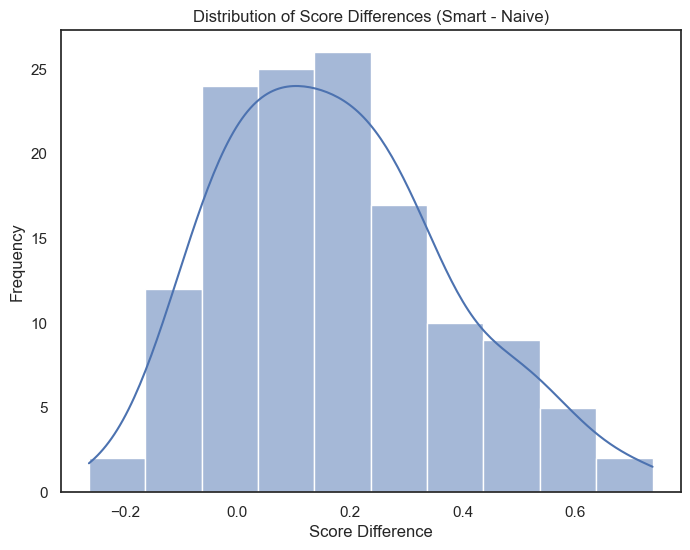

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

score_diffs = [smart_mean - naive_mean for naive_mean, smart_mean in zip(naive_means, smart_means)]

plt.figure(figsize=(8, 6))
sns.histplot(score_diffs, kde=True)
plt.title('Distribution of Score Differences (Smart - Naive)')
plt.xlabel('Score Difference')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# highlight those documents where the smart system outperforms the naive system
naive_medians = list(system_to_doc_to_median["naive"].values())
smart_medians = list(system_to_doc_to_median["smart"].values())
doc_names = list(system_to_doc_to_median["naive"].keys())

df = pd.DataFrame({
    'Document': doc_names,
    'Naive System': naive_medians,
    'Smart System': smart_medians
})

df = df.melt('Document', var_name='System', value_name='Median Answer Relevancy')
sns.set(rc={'figure.figsize':(15,9)})
sns.barplot(x='Document', y='Median Answer Relevancy', hue='System', data=df)
# replace document names with doc_0, doc_1, etc.
plt.xticks(range(len(doc_names)), [f"doc_{i}" for i in range(len(doc_names))])
# highlight those documents where the smart system outperforms the naive system
for i, (naive_median, smart_median) in enumerate(zip(naive_medians, smart_medians)):
    if smart_median > naive_median:
        plt.gca().get_xticklabels()[i].set_color('red')
plt.show()

In [16]:
naive_scores = []
smart_scores = []

# tally over systems, mean over everything 
for file in sorted(os.listdir(naive_eval_path)):
    # doc_name = file.split(".")[0].split("_")[1]
    doc_name = file[file.find("naive")+len('naive')+1:]
    df = pd.read_csv(os.path.join(naive_eval_path, file))
    naive_scores.extend(df['answer_relevancy'].to_list())

for file in sorted(os.listdir(smart_eval_path)):
    # doc_name = file.split(".")[0].split("_")[1]
    doc_name = file[file.find("smart")+len('naive')+1:]
    df = pd.read_csv(os.path.join(smart_eval_path, file))
    smart_scores.extend(df['answer_relevancy'].to_list())


In [17]:
# mean over everything
naive_mean = sum(naive_scores) / len(naive_scores)
smart_mean = sum(smart_scores) / len(smart_scores)

# median over everything
naive_median = sorted(naive_scores)[len(naive_scores) // 2]
smart_median = sorted(smart_scores)[len(smart_scores) // 2]

# sd over everything
naive_sd = sum([(score - naive_mean) ** 2 for score in naive_scores]) / len(naive_scores)
naive_sd = naive_sd ** 0.5
smart_sd = sum([(score - smart_mean) ** 2 for score in smart_scores]) / len(smart_scores)
smart_sd = smart_sd ** 0.5

print(f"Naive system mean answer relevancy: {naive_mean}")
print(f"Smart system mean answer relevancy: {smart_mean}")
print(f"Naive system median answer relevancy: {naive_median}")
print(f"Smart system median answer relevancy: {smart_median}")
print(f"Naive system standard deviation: {naive_sd}")
print(f"Smart system standard deviation: {smart_sd}")

Naive system mean answer relevancy: 0.43454890678189967
Smart system mean answer relevancy: 0.6094887448312514
Naive system median answer relevancy: 0.0
Smart system median answer relevancy: 0.7676013963265963
Naive system standard deviation: 0.4479200151175059
Smart system standard deviation: 0.35688237718459265
